# Import Libraries

In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from tensorflow.keras import layers,models,callbacks,regularizers
from tensorflow.keras.callbacks import ModelCheckpoint,CSVLogger
from sklearn.metrics import classification_report, confusion_matrix,precision_recall_curve, average_precision_score
from sklearn.utils import class_weight

# Set Random seed

In [2]:
tf.keras.utils.set_random_seed(42)

# Loading Datasets

In [3]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


# Data Preprocessing

## Drop id column

In [7]:
df.drop(columns = ['id'],inplace=True)

drop id column, because this column doesn't contain any useful information as a predictor

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


Based on the df.info() summary, the bmi column contains 201 missing values because it only has 4,909 non-null entries out of the total 5,110 rows.Based on the df.info() summary, the bmi column contains 201 missing values because it only has 4,909 non-null entries out of the total 5,110 rows.

## Checking for duplicated value

In [9]:
print(df.duplicated().sum())

0


There isn't any duplicated value

## Checking for missing value

In [10]:
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


Those are 201 missing values in bmi column

## Checking for inconsistent value in categorical variables

In [11]:
cat_col = ['gender','ever_married','work_type','Residence_type','smoking_status','hypertension','heart_disease']

In [12]:
for col in cat_col :
    print(df[col].value_counts())

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64
ever_married
Yes    3353
No     1757
Name: count, dtype: int64
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64
hypertension
0    4612
1     498
Name: count, dtype: int64
heart_disease
0    4834
1     276
Name: count, dtype: int64


In [13]:
df['gender'] = df['gender'].replace('Other','Female')

The single 'Other' value in the gender column is replaced with 'Female' to ensure stability during data splitting, as having only one sample in a category can cause errors in stratified training and validation sets.

## Checking descriptive statistics for numerical variables

In [14]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## Showing boxplot and histogram for numerical variables

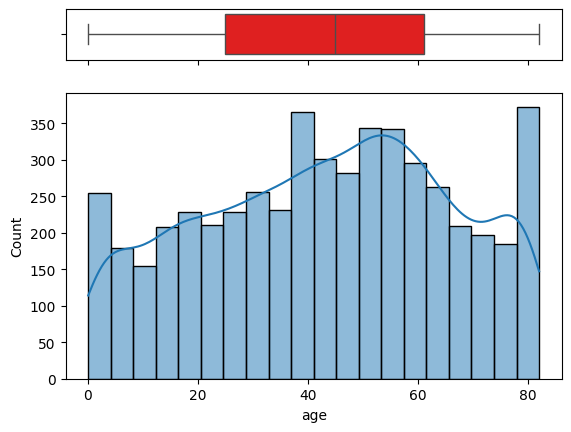

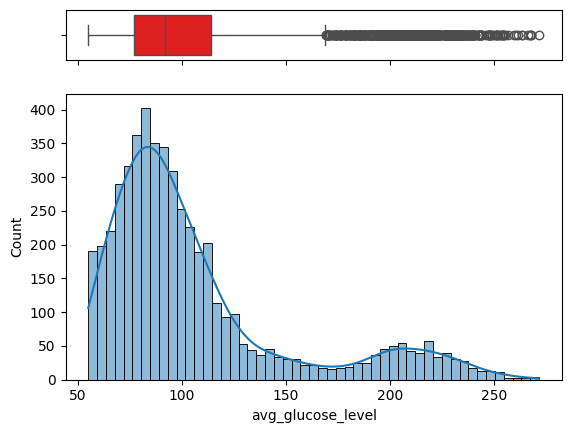

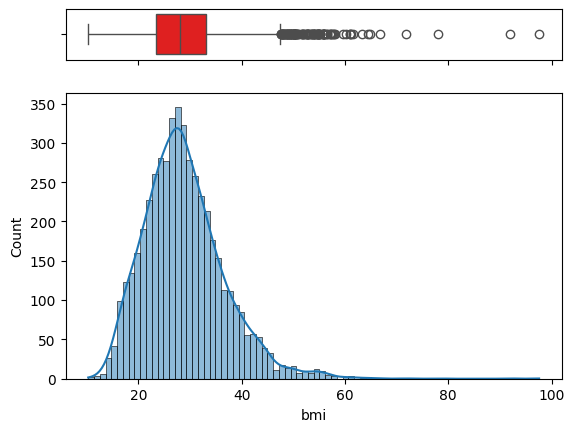

In [15]:

num_col = ['age','avg_glucose_level','bmi']
for col in num_col :
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})
 

    sns.boxplot(df[col], ax=ax_box, orient="h", color="red")

    sns.histplot(df[col], ax=ax_hist, kde=True)
 
    ax_box.set(xlabel='')
    plt.show()

The graphs show that ages range evenly from babies to seniors, BMI is mostly normal but has many extreme outliers, and glucose levels are split into two groups: those with healthy levels and those at high risk.

## Checking for multicollinearity in numerical variable

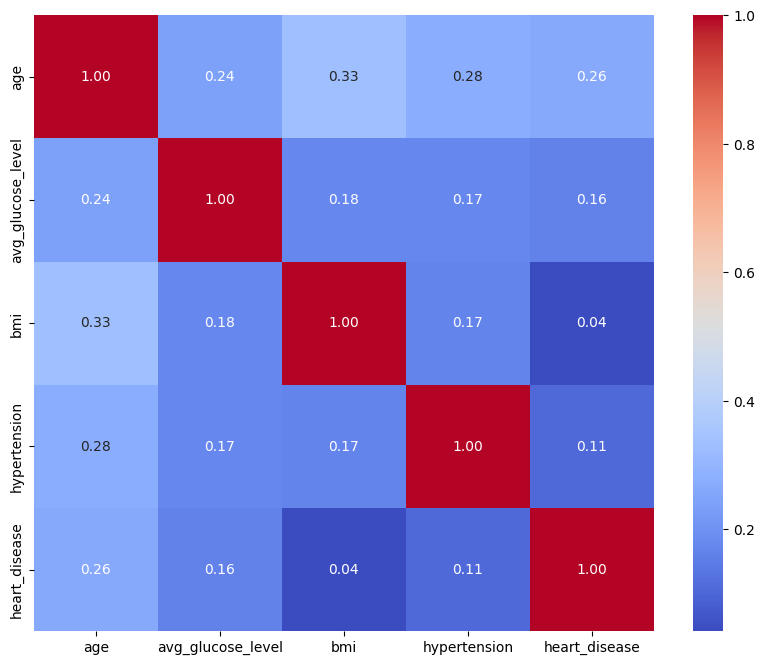

In [16]:
cols_to_check = num_col + ['hypertension', 'heart_disease']
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_to_check].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

The correlation heatmap confirms the absence of multicollinearity, as all coefficients between numerical variables are low, with the highest correlation being only 0.33 between age and BMI.

## Checking for imbalance

C:\Users\andro\AppData\Local\Temp\ipykernel_35000\1505955611.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='viridis')


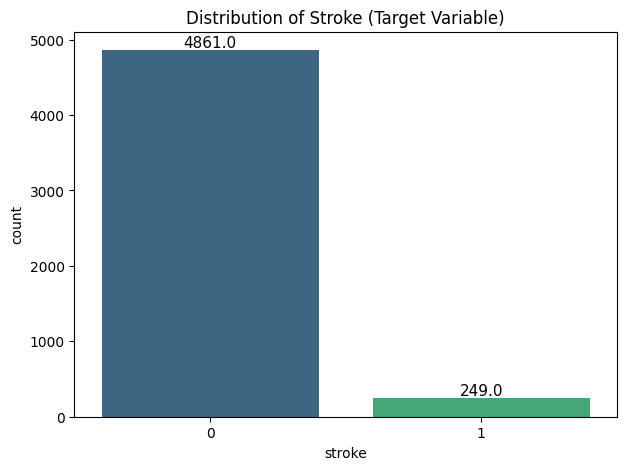

In [17]:

plt.figure(figsize=(7, 5))
sns.countplot(x='stroke', data=df, palette='viridis')


ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribution of Stroke (Target Variable)')
plt.show()

The bar plot illustrates a severe class imbalance in the target variable, where only 249 cases of stroke are recorded compared to 4,861 non-stroke instances, resulting in a 4.8% prevalence rate.

## Splitting into x and y

In [18]:
x = df.drop(columns = ['stroke'])

In [19]:
x.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked


In [20]:
y = df['stroke']

## Splitting into train , validation, and test 

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x,y,random_state= 42, stratify = y, test_size=0.2)

In [22]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, stratify=y_train, random_state=42)

The data is partitioned into training, validation, and testing sets with a 60:20:20 ratio using stratified sampling based on the target variable to ensure the minority stroke class is proportionally represented in every split for reliable performance measurement.

## Pipeline for impute missing values, log transformation (for skewed right column), scaling, and encoding

In [23]:
heavy_num_cols = ['avg_glucose_level', 'bmi']
light_num_cols = ['age']
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

In [24]:
heavy_num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)), 
    ('scaler', RobustScaler()) 
])

In [25]:
light_num_pipeline = Pipeline([
    ('scaler', RobustScaler())
])

In [26]:
preprocessor = ColumnTransformer([
    
    ('heavy',heavy_num_pipeline, heavy_num_cols),
    ('light',light_num_pipeline, light_num_cols),
    ('cat', OneHotEncoder(sparse_output=False, drop = 'first'), cat_cols),
    ('bin', 'passthrough', ['hypertension', 'heart_disease'])
])

In [27]:
x_train = preprocessor.fit_transform(x_train)
x_val = preprocessor.transform(x_val)
x_test = preprocessor.transform(x_test)

This automated ColumnTransformer pipeline integrates median imputation for missing data, log transformations to normalize right-skewed features, and RobustScaler to handle outliers, while applying one-hot encoding to categorical variables for consistent data preparation across all dataset splits.

## Build ANN Models

## Handling Imbalance class

In [28]:
weights = class_weight.compute_class_weight('balanced', classes = np.unique(y_train), y = y_train)
class_weight_dict = dict(enumerate(weights))

Since the stroke dataset is highly imbalanced (only around 4.8% positive cases), I calculate class weights to give more importance to the minority class during training.

## Build sequential model

In [29]:
print(f"Total Features {x_train.shape[1]}")

Total Features 15


In [30]:
model_seq = models.Sequential(
    [
        layers.Input(shape = (x_train.shape[1],)),
        layers.Dense(32,activation = 'relu'),
        layers.Dropout(0.2),
        layers.Dense(16, activation= 'relu'),
        layers.Dense(1, activation='sigmoid')
    ]
)

## Build Functional Model

In [31]:
inputs = layers.Input(shape=(x_train.shape[1],))

x = layers.Dense(32, activation= 'relu')(inputs)
x = layers.Dropout(0.2)(x)

x = layers.Dense(16, activation= 'relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_func = models.Model(inputs=inputs, outputs=outputs, name="ANN_Functional")

The Sequential model is a simple linear stack of layers ideal for straightforward models, while the Functional model is more flexible, allowing for complex architectures with multiple inputs, outputs, or shared layers. Although my current code builds identical architectures with both methods, the Functional model is better suited for advanced features like skip connections that could improve deep learning stability. Effectively, Sequential is for speed and simplicity, whereas Functional is designed for research and complex model design.

## Using early stopping due to avoid overfitting 

In [32]:
early_stop = callbacks.EarlyStopping(
    monitor='val_recall',
    patience=25, 
    restore_best_weights=True
)

The EarlyStopping callback monitors val_recall to halt training when the model stops improving its ability to detect actual stroke cases, preserving the best possible weights. Focusing on Recall is critical because missing a diagnosis (False Negative) is life-threatening in medical contexts, and it ensures the model effectively learns from the 4.8% minority class rather than just predicting "no stroke" for everyone.

## Compile Model

In [33]:
model_func.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate= 0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy',tf.keras.metrics.Recall(name='recall')]
)

The model is configured with the Adam optimizer at a specific learning rate of 0.0001 and uses binary crossentropy as the loss function for this classification task. It tracks both Accuracy and Recall to monitor how well the model balances overall correctness with its primary goal of detecting actual stroke cases.

## CSV Logger

In [34]:
csv_log = CSVLogger('log_training_stroke.csv', separator=',', append=False)

The CSVLogger callback is used to record the model's training progress, saving metrics like loss and recall per epoch into a CSV file for permanent storage and later review. By configuring append=False, the logger ensures that the results from previous runs are cleared so only the most recent training session's data is preserved.

## Checkpoints

In [ ]:
checkpoint = ModelCheckpoint(
    'best_model.keras', 
    monitor='val_recall',        
    save_best_only=True,       
    mode='max'    )               

The ModelCheckpoint callback automatically saves model weights to 'model_stroke_terbaik.keras' every time the model reaches a new peak in validation recall. This safeguards the training process by ensuring the most effective version of the model is preserved, even if performance declines in later epochs.

## Checking GPU

In [36]:
print("Num GPUs available : ", len(tf.config.list_physical_devices('GPU')))

if tf.config.list_physical_devices('GPU'):
    print("GPU Name:",tf.config.list_physical_devices('GPU')[0] )
else :
    print("GPU not detected")

Num GPUs available :  1
GPU Name: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


checking gpu availability to compile and train the models

In [37]:
with tf.device('/GPU:0'):
    history  = model_func.fit(
        x_train,y_train,
        epochs = 100,
        batch_size = 32,
        validation_data=(x_val, y_val),
        callbacks = [early_stop, checkpoint, csv_log],
        class_weight = class_weight_dict
    )

Epoch 1/100
96/96 [==============================] - 5s 11ms/step - loss: 0.6986 - accuracy: 0.2231 - recall: 0.8456 - val_loss: 0.7676 - val_accuracy: 0.2583 - val_recall: 0.9000
Epoch 2/100
96/96 [==============================] - 0s 5ms/step - loss: 0.6906 - accuracy: 0.2590 - recall: 0.8456 - val_loss: 0.7582 - val_accuracy: 0.2730 - val_recall: 0.9000
Epoch 3/100
96/96 [==============================] - 0s 5ms/step - loss: 0.6810 - accuracy: 0.2919 - recall: 0.8792 - val_loss: 0.7459 - val_accuracy: 0.3131 - val_recall: 0.9000
Epoch 4/100
96/96 [==============================] - 1s 6ms/step - loss: 0.6739 - accuracy: 0.3327 - recall: 0.8993 - val_loss: 0.7388 - val_accuracy: 0.3513 - val_recall: 0.9000
Epoch 5/100
96/96 [==============================] - 1s 7ms/step - loss: 0.6667 - accuracy: 0.3584 - recall: 0.8591 - val_loss: 0.7306 - val_accuracy: 0.4080 - val_recall: 0.9000
Epoch 6/100
96/96 [==============================] - 1s 7ms/step - loss: 0.6591 - accuracy: 0.4217 - rec

The model training is executed on a GPU for 100 epochs using a batch size of 32, integrating the automated callbacks to ensure efficient monitoring and performance preservation

# Evaluation 

## Loss and Recall Visualization

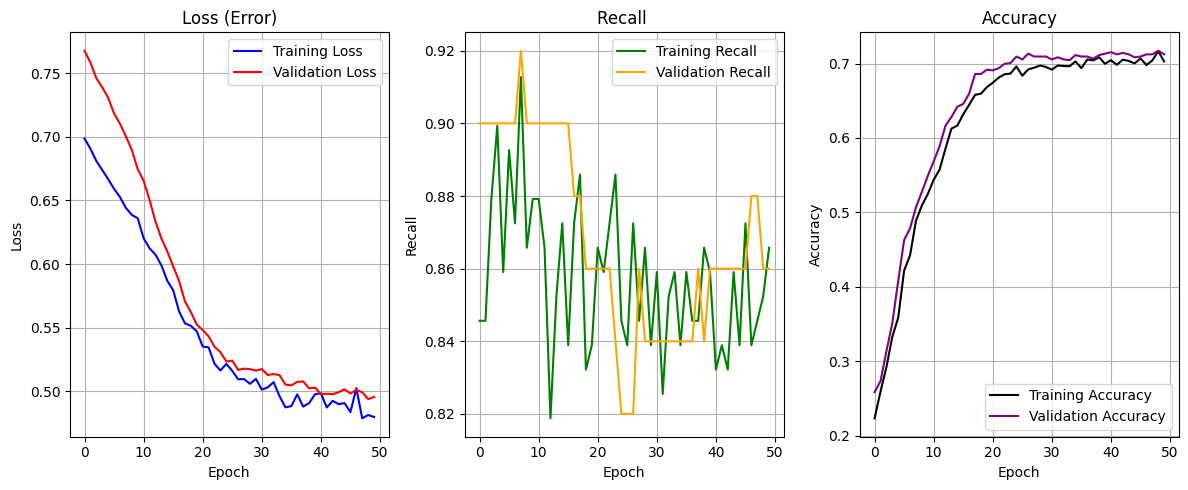

In [38]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Loss (Error)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.subplot(1, 3, 2)
plt.plot(history.history['recall'], label='Training Recall', color='green')
plt.plot(history.history['val_recall'], label='Validation Recall', color='orange')
plt.title('Recall ')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='black')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

The training curves demonstrate healthy convergence, with loss steadily decreasing and accuracy stabilizing around 70% while validation recall remains consistently high between 0.82 and 0.92. The close alignment between the training and validation lines indicates that the model is well-regularized and generalizes effectively without significant overfitting. This high stable recall confirms that the class weighting strategy is successfully prioritizing the detection of the 4.8% minority stroke cases.

## Predict using x_test

In [39]:
y_pred_probs = model_func.predict(x_test)

32/32 [==============================] - 0s 2ms/step


In [40]:
y_pred = (y_pred_probs > 0.5).astype("int32")

The model calculates probability scores for the test data using the predict function, which are then converted into binary class labels using a 0.5 threshold. This thresholding step transforms the continuous output into discrete "stroke" or "no-stroke" predictions, allowing for a final assessment of the model's performance on unseen data.

## Confusion Matrix

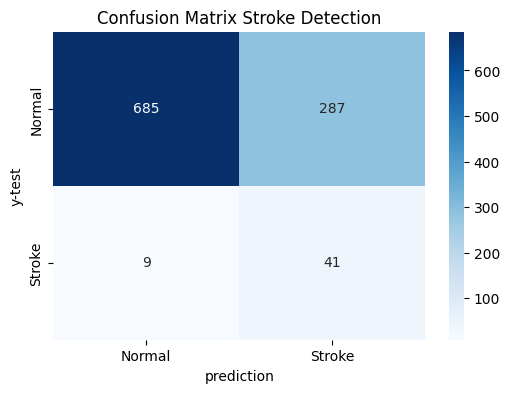

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Stroke'], 
            yticklabels=['Normal', 'Stroke'])
plt.xlabel('prediction')
plt.ylabel('y-test')
plt.title('Confusion Matrix Stroke Detection')
plt.show()

The confusion matrix reveals a deliberate medical trade-off: the model successfully identified 41 stroke cases but produced 287 False Positives. This strategy prioritizes Recall over Precision, as it is far more critical in a healthcare setting to issue a "false alarm" than to miss a life-threatening stroke case (False Negative), of which only 9 occurred. This high-recall model is now fully optimized and saved for deployment in a backend environment.

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.70      0.82       972
           1       0.12      0.82      0.22        50

    accuracy                           0.71      1022
   macro avg       0.56      0.76      0.52      1022
weighted avg       0.94      0.71      0.79      1022



While the overall accuracy of 71% might seem modest, it is not a performance issue because the model successfully prioritizes a high Recall of 0.82 for the minority stroke class. In this dataset, where only 4.8% of patients actually suffered a stroke, a model could easily achieve 95% accuracy by simply predicting that no one will ever have a stroke. However, such a model would have a 0% Recall, meaning it would fail to identify every single actual stroke patient, which is a life-threatening failure in a medical diagnostic setting.

The current results demonstrate a strategic trade-off where the model correctly identified 41 out of 50 actual stroke cases in the test set. While this approach leads to 287 False Positives (healthy patients flagged as high risk), this is the preferred outcome for stroke prevention. It is far more acceptable to conduct further medical screenings on a healthy patient than to allow 9 patients to go undiagnosed and untreated. Therefore, this model is significantly more reliable for clinical use than a high-accuracy model that ignores the minority class.

## Precision Recall Curve

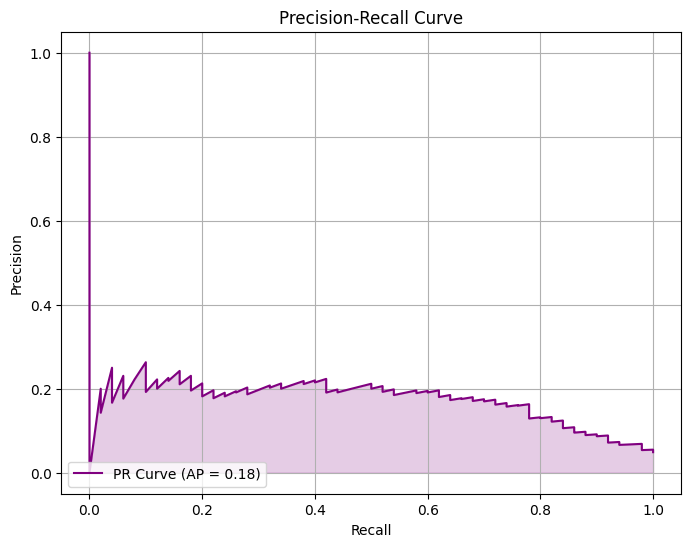

In [43]:

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)


ap_score = average_precision_score(y_test, y_pred_probs)


plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', label=f'PR Curve (AP = {ap_score:.2f})')
plt.fill_between(recall, precision, alpha=0.2, color='purple')

plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

In a dataset with only 4.8% stroke prevalence, the "No-Skill" baseline for Average Precision (AP) is a mere 0.048, representing the success rate of a model that simply guesses randomly. The model’s AP of 0.18 is a significant achievement because it is mathematically 3.75 times (nearly 4x) more effective than random chance at identifying the minority stroke class. The score is suppressed to 0.18 only because we deliberately prioritized a high Recall of 0.82 to prevent life-threatening False Negatives, a safety-first strategy that naturally accepts 287 False Positives and pulls Precision down to 0.12. Ultimately, this 0.18 AP proves the model has captured meaningful patterns far beyond random guessing while maintaining the high sensitivity required for medical diagnostics.